         Patient_ID           Age  Blood_Pressure   Sugar_Level   Cholesterol  \
count  10000.000000  10000.000000    10000.000000  10000.000000  10000.000000   
mean    5020.929200     49.503400      129.719800    134.633200    223.746800   
std     2918.365524     17.361012       28.833259     37.572948     43.409146   
min        2.000000     20.000000       80.000000     70.000000    150.000000   
25%     2461.000000     34.000000      104.000000    102.000000    186.000000   
50%     5012.000000     50.000000      130.000000    134.000000    223.000000   
75%     7563.500000     64.000000      155.000000    167.000000    262.000000   
max     9998.000000     79.000000      179.000000    199.000000    299.000000   

         Heart_Rate  
count  10000.000000  
mean      89.572100  
std       17.209428  
min       60.000000  
25%       75.000000  
50%       89.000000  
75%      104.000000  
max      119.000000  
7808
Gender
Female    129.811422
Male      129.626589
Name: Blood_Pressu

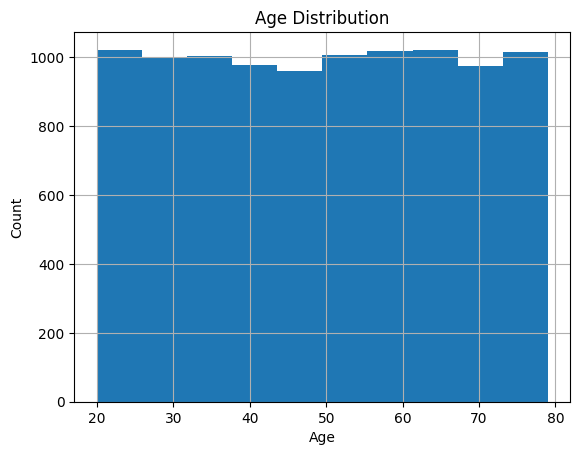

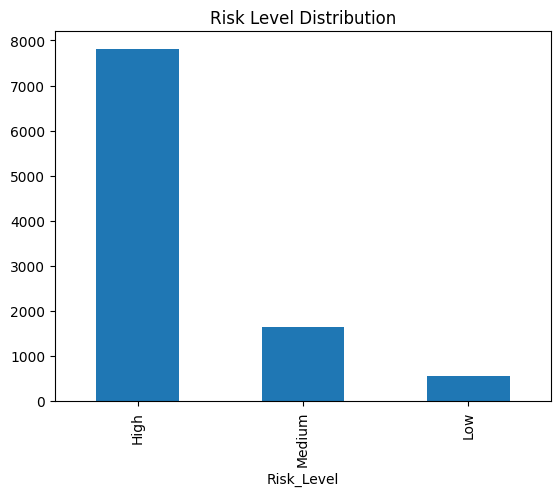

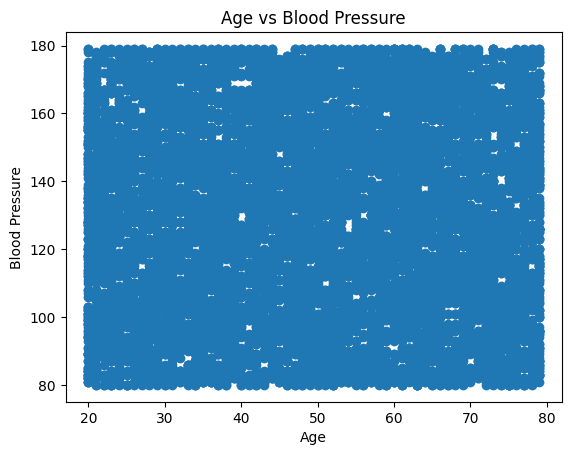

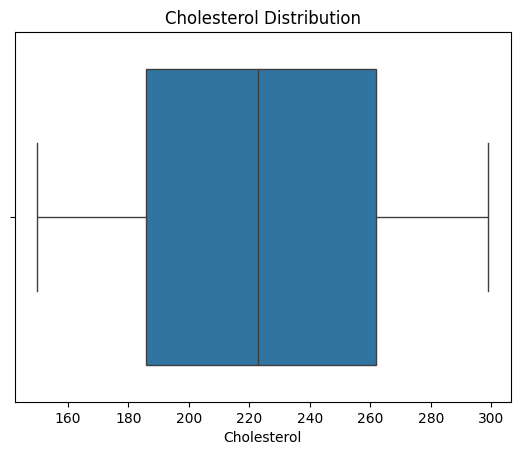

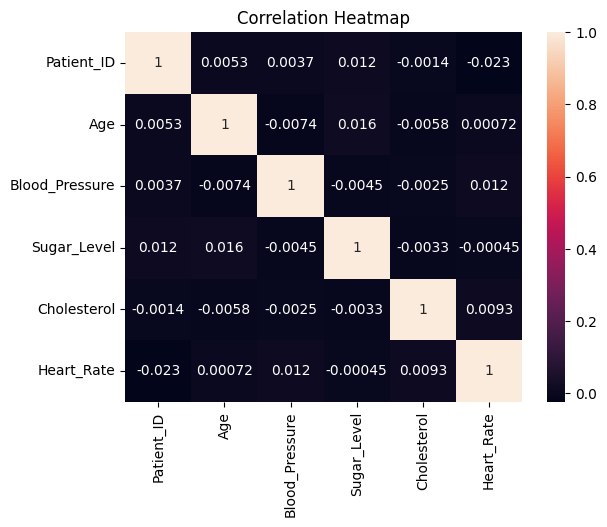

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data={
"Patient_ID":np.random.randint(1,10000,10000),
"Age":np.random.randint(20,80,10000),
"Gender":np.random.choice(["Male","Female"],10000),
"Blood_Pressure":np.random.randint(80,180,10000),
"Sugar_Level":np.random.randint(70,200,10000),
"Cholesterol":np.random.randint(150,300,10000),
"Heart_Rate":np.random.randint(60,120,10000)
}

df=pd.DataFrame(data)

df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True),inplace=True)

def classify_risk(row):
    if(row["Blood_Pressure"]>140 or row["Sugar_Level"]>180 or row["Cholesterol"]>240 or row["Heart_Rate"]>100):return"High"
    elif(row["Blood_Pressure"]>120 or row["Sugar_Level"]>140 or row["Cholesterol"]>200):return"Medium"
    else:return"Low"

df["Risk_Level"]=df.apply(classify_risk,axis=1)

print(df.describe())
high_risk=df[df["Risk_Level"]=="High"]
print(len(high_risk))
print(df.groupby("Gender")["Blood_Pressure"].mean())
print(df.groupby("Risk_Level").size())

df["Age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()

plt.scatter(df["Age"],df["Blood_Pressure"])
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Age vs Blood Pressure")
plt.show()

sns.boxplot(x=df["Cholesterol"])
plt.title("Cholesterol Distribution")
plt.show()

corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df


,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,734,55,Male,177,157,263,78
1,788,36,Female,114,170,162,89
2,6775,63,Male,136,98,250,91
3,3619,22,Female,178,86,175,105
4,2317,47,Male,165,116,170,117
...,...,...,...,...,...,...,...
9995,8015,60,Male,136,96,181,73
9996,4142,64,Female,81,146,164,76
9997,8331,48,Female,119,88,197,96
9998,8149,45,Female,85,89,224,72
